# 11_v2. Clasificacion mejorada de eventos de perdida


## Enfoque de esta version

Esta version profundiza la formulacion categorica del proyecto. El objetivo es mejorar la deteccion de eventos relevantes de perdida anual mediante una combinacion de: validacion temporal mas adecuada para eventos raros, manejo controlado del desbalance dentro del entrenamiento, grilla de umbrales mas fina y una comparacion ampliada entre clasificadores.

La logica general se mantiene: la validacion principal sigue ocurriendo sobre la capa anual, mientras que la capa mensual se usara despues para operacionalizar la senal en alertas y trigger.


## Dependencias y librerias esperadas

Esta version mantiene las librerias base de clasificacion y agrega dependencias opcionales que amplian la comparacion:

- `imbalanced-learn` para sobre-muestreo y bosques balanceados
- `catboost` para una alternativa boosting adicional orientada a datos tabulares
- `xgboost` y `lightgbm` como familias avanzadas de boosting ya probadas en la fase de regresion

Si alguna libreria opcional no esta disponible, el cuaderno continua y simplemente omite esa familia.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

SKLEARN_AVAILABLE = True
try:
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression, RidgeClassifier
    from sklearn.ensemble import (
        RandomForestClassifier,
        ExtraTreesClassifier,
        GradientBoostingClassifier,
        HistGradientBoostingClassifier,
        AdaBoostClassifier,
    )
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import roc_auc_score
except Exception:
    SKLEARN_AVAILABLE = False

IMBLEARN_AVAILABLE = True
try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
except Exception:
    IMBLEARN_AVAILABLE = False

XGBOOST_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception:
    XGBOOST_AVAILABLE = False

LIGHTGBM_AVAILABLE = True
try:
    from lightgbm import LGBMClassifier
except Exception:
    LIGHTGBM_AVAILABLE = False

CATBOOST_AVAILABLE = True
try:
    from catboost import CatBoostClassifier
except Exception:
    CATBOOST_AVAILABLE = False

MATPLOTLIB_AVAILABLE = True
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    MATPLOTLIB_AVAILABLE = False


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro la carpeta BASE_DE_DATOS.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
INPUT_PATH = PROJECT_ROOT / 'BASE_DE_DATOS' / 'FINALES' / 'dataset_modelado_anual_limpio.csv'
OUTPUT_DIR = PROJECT_ROOT / 'MODELOS' / 'resultados_11_v2_clasificacion_mejorada'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No se encontro la base anual esperada: {INPUT_PATH}')

print('Base anual localizada correctamente.')
print('Archivo principal de entrada:', INPUT_PATH.name)
print('Carpeta de resultados:', OUTPUT_DIR.name)


Base anual localizada correctamente.
Archivo principal de entrada: dataset_modelado_anual_limpio.csv
Carpeta de resultados: resultados_11_v2_clasificacion_mejorada


## Carga de la base anual final

La clasificacion se monta sobre la misma capa anual utilizada en la regresion. Esto garantiza consistencia metodologica entre magnitud continua y eventos.


In [3]:
df = pd.read_csv(INPUT_PATH, sep=';').sort_values(['departamento', 'anio']).reset_index(drop=True)

if 'es_risaralda' not in df.columns:
    df['es_risaralda'] = (
        df['departamento']
        .astype(str)
        .str.strip()
        .str.lower()
        .eq('risaralda')
        .astype(int)
    )
    print('Se creo la columna auxiliar es_risaralda a partir de departamento.')

TARGET = 'evento_perdida_anual'
SUPPORT_TARGET = 'perdida_rendimiento_anual_pct'

print('Shape base anual:', df.shape)
print('Anios cubiertos:', int(df['anio'].min()), '-', int(df['anio'].max()))
print('Departamentos:', sorted(df['departamento'].unique().tolist()))
print('Eventos positivos:', int(df[TARGET].sum()))
print('Eventos negativos:', int((df[TARGET] == 0).sum()))

target_profile = pd.DataFrame([
    {
        'target': TARGET,
        'tipo': 'binario',
        'n_total': len(df),
        'n_eventos': int(df[TARGET].sum()),
        'proporcion_eventos': float(df[TARGET].mean()),
        'soporte_continuo': SUPPORT_TARGET,
    }
])
display(target_profile)



Se creo la columna auxiliar es_risaralda a partir de departamento.
Shape base anual: (36, 81)
Anios cubiertos: 2007 - 2024
Departamentos: ['Cundinamarca', 'Risaralda']
Eventos positivos: 7
Eventos negativos: 29


,target,tipo,n_total,n_eventos,proporcion_eventos,soporte_continuo
0,evento_perdida_anual,binario,36,7,0.194444,perdida_rendimiento_anual_pct


## Parametros del experimento

En esta version se ajusta la validacion temporal para que la clasificacion no quede dominada por ventanas tardias sin eventos. Tambien se amplia la grilla de umbrales para explorar mejor el compromiso entre precision y recall.


In [4]:
TRAIN_END_YEAR = 2020
TEST_START_YEAR = 2021
SMALL_TRAIN_END_YEAR = 2016
SMALL_VALID_END_YEAR = 2020
CV_MIN_TRAIN_YEARS = 4
CV_VALID_WINDOW = 2
THRESHOLDS = [round(x, 2) for x in np.arange(0.10, 0.91, 0.05).tolist()]

dependency_report = pd.DataFrame([
    {'dependencia': 'scikit-learn', 'disponible': SKLEARN_AVAILABLE},
    {'dependencia': 'imbalanced-learn', 'disponible': IMBLEARN_AVAILABLE},
    {'dependencia': 'xgboost', 'disponible': XGBOOST_AVAILABLE},
    {'dependencia': 'lightgbm', 'disponible': LIGHTGBM_AVAILABLE},
    {'dependencia': 'catboost', 'disponible': CATBOOST_AVAILABLE},
    {'dependencia': 'matplotlib', 'disponible': MATPLOTLIB_AVAILABLE},
])
display(dependency_report)


,dependencia,disponible
0,scikit-learn,True
1,imbalanced-learn,True
2,xgboost,True
3,lightgbm,True
4,catboost,False
5,matplotlib,True


## Helpers de evaluacion y validacion temporal

Esta fase incorpora dos cambios relevantes:

- los folds temporales ahora se resumen explicitamente para verificar cuantos eventos aparecen en entrenamiento y validacion
- la seleccion del umbral ya no se apoya solo en metricas promedio generales, sino tambien en metricas calculadas sobre folds que si contienen eventos positivos


In [5]:
run_log = []


def log(msg: str):
    run_log.append(msg)
    print(msg)


def safe_write_text(path: Path, text: str):
    path.write_text(text, encoding='utf-8')


def dependency_status_text(dep_df: pd.DataFrame):
    out = {}
    for _, row in dep_df.iterrows():
        out[str(row['dependencia'])] = bool(row['disponible'])
    return out


def make_expanding_year_folds(train_df: pd.DataFrame, min_train_years: int, valid_window: int):
    years = sorted(train_df['anio'].unique().tolist())
    folds = []
    summary_rows = []
    for cutoff_pos in range(min_train_years, len(years) - valid_window + 1):
        train_years = years[:cutoff_pos]
        valid_years = years[cutoff_pos: cutoff_pos + valid_window]
        tr_mask = train_df['anio'].isin(train_years)
        va_mask = train_df['anio'].isin(valid_years)
        tr_idx = train_df.index[tr_mask].tolist()
        va_idx = train_df.index[va_mask].tolist()
        tr_pos = int(train_df.loc[tr_mask, TARGET].sum())
        va_pos = int(train_df.loc[va_mask, TARGET].sum())
        summary_rows.append({
            'train_years': ', '.join([str(y) for y in train_years]),
            'valid_years': ', '.join([str(y) for y in valid_years]),
            'n_train': len(tr_idx),
            'n_valid': len(va_idx),
            'positivos_train': tr_pos,
            'positivos_valid': va_pos,
            'fold_usable': len(tr_idx) > 0 and len(va_idx) > 0 and tr_pos >= 2,
        })
        if len(tr_idx) > 0 and len(va_idx) > 0 and tr_pos >= 2:
            folds.append({
                'train_years': train_years,
                'valid_years': valid_years,
                'train_idx': tr_idx,
                'valid_idx': va_idx,
                'train_pos': tr_pos,
                'valid_pos': va_pos,
            })
    return folds, pd.DataFrame(summary_rows)


def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, y_score))
    except Exception:
        return np.nan


def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    total = max(len(y_true), 1)
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    positive_rate_pred = float(y_pred.mean())
    roc_auc = safe_auc(y_true, y_score)

    return {
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1': float(f1),
        'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        'positive_rate_pred': positive_rate_pred,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def choose_best_threshold(fold_payloads, thresholds):
    rows = []
    for thr in thresholds:
        metrics = [classification_metrics(y_true, y_score, threshold=thr) for y_true, y_score in fold_payloads]
        event_metrics = [
            classification_metrics(y_true, y_score, threshold=thr)
            for y_true, y_score in fold_payloads
            if np.sum(np.asarray(y_true).astype(int)) > 0
        ]
        rows.append({
            'threshold': thr,
            'cv_accuracy_mean': float(np.mean([m['accuracy'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_balanced_accuracy_mean': float(np.mean([m['balanced_accuracy'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_precision_mean': float(np.mean([m['precision'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_recall_mean': float(np.mean([m['recall'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_specificity_mean': float(np.mean([m['specificity'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_f1_mean': float(np.mean([m['f1'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_roc_auc_mean': float(np.nanmean([m['roc_auc'] for m in metrics])) if len(metrics) > 0 else np.nan,
            'cv_event_folds': len(event_metrics),
            'cv_recall_event_mean': float(np.mean([m['recall'] for m in event_metrics])) if len(event_metrics) > 0 else 0.0,
            'cv_precision_event_mean': float(np.mean([m['precision'] for m in event_metrics])) if len(event_metrics) > 0 else 0.0,
            'cv_f1_event_mean': float(np.mean([m['f1'] for m in event_metrics])) if len(event_metrics) > 0 else 0.0,
        })
    thr_df = pd.DataFrame(rows).sort_values(
        ['cv_recall_event_mean', 'cv_f1_event_mean', 'cv_precision_event_mean', 'cv_balanced_accuracy_mean', 'cv_accuracy_mean'],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)
    return thr_df.iloc[0].to_dict(), thr_df


## Definicion de datasets experimentales

Ademas de separar entrenamiento y prueba, esta fase muestra explicitamente los folds temporales posibles y cuantas observaciones positivas contienen.


In [6]:
main_train = df.loc[df['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
main_test = df.loc[df['anio'] >= TEST_START_YEAR].copy().reset_index(drop=True)

small_train = df.loc[df['anio'] <= SMALL_TRAIN_END_YEAR].copy().reset_index(drop=True)
small_valid = df.loc[(df['anio'] > SMALL_TRAIN_END_YEAR) & (df['anio'] <= SMALL_VALID_END_YEAR)].copy().reset_index(drop=True)

split_summary = pd.DataFrame([
    {
        'split': 'train_principal',
        'anios': f"{int(main_train['anio'].min())}-{int(main_train['anio'].max())}",
        'n_obs': len(main_train),
        'n_eventos': int(main_train[TARGET].sum()),
    },
    {
        'split': 'test_principal',
        'anios': f"{int(main_test['anio'].min())}-{int(main_test['anio'].max())}",
        'n_obs': len(main_test),
        'n_eventos': int(main_test[TARGET].sum()),
    },
    {
        'split': 'train_small',
        'anios': f"{int(small_train['anio'].min())}-{int(small_train['anio'].max())}",
        'n_obs': len(small_train),
        'n_eventos': int(small_train[TARGET].sum()),
    },
    {
        'split': 'valid_small',
        'anios': f"{int(small_valid['anio'].min())}-{int(small_valid['anio'].max())}",
        'n_obs': len(small_valid),
        'n_eventos': int(small_valid[TARGET].sum()),
    },
])
display(split_summary)

folds_preview, fold_summary = make_expanding_year_folds(main_train, CV_MIN_TRAIN_YEARS, CV_VALID_WINDOW)
print('Numero de folds temporales utilizables:', len(folds_preview))
display(fold_summary)


,split,anios,n_obs,n_eventos
0,train_principal,2007-2020,28,5
1,test_principal,2021-2024,8,2
2,train_small,2007-2016,20,5
3,valid_small,2017-2020,8,0


Numero de folds temporales utilizables: 7


,train_years,valid_years,n_train,n_valid,positivos_train,positivos_valid,fold_usable
0,"2007, 2008, 2009, 2010","2011, 2012",8,4,1,1,False
1,"2007, 2008, 2009, 2010, 2011","2012, 2013",10,4,1,3,False
2,"2007, 2008, 2009, 2010, 2011, 2012","2013, 2014",12,4,2,3,True
3,"2007, 2008, 2009, 2010, 2011, 2012, 2013","2014, 2015",14,4,4,1,True
4,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014","2015, 2016",16,4,5,0,True
5,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2016, 2017",18,4,5,0,True
6,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2017, 2018",20,4,5,0,True
7,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2018, 2019",22,4,5,0,True
8,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2019, 2020",24,4,5,0,True


## Construccion de estrategias de variables

Se reutiliza el enfoque de la fase anual continua para mantener comparabilidad entre ambas formulaciones.


In [7]:
baseline_parsimonioso = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean',
]

annual_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
]

harvest_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'def_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean',
]

annual_plus_terrain = annual_core + ['elevacion_media_m', 'pendiente_media']

satellite_focus = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'NDVI_annual_mean',
    'EVI_annual_mean',
    'Gpp_annual_mean',
    'Lai_500m_annual_mean',
    'NDVI_anomalia_pct_cosecha_mean',
    'EVI_anomalia_pct_cosecha_mean',
    'Gpp_anomalia_pct_cosecha_mean',
]

manual_feature_sets = {
    'baseline_parsimonioso': baseline_parsimonioso,
    'annual_core': annual_core,
    'harvest_core': harvest_core,
    'annual_plus_terrain': annual_plus_terrain,
    'satellite_focus': satellite_focus,
}

train_for_selection = main_train.copy()
candidate_cols = []
for cols in manual_feature_sets.values():
    candidate_cols.extend(cols)
candidate_cols = sorted(list(dict.fromkeys([c for c in candidate_cols if c in train_for_selection.columns])))

corr_series = train_for_selection[candidate_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
corr_top8_train = corr_series.head(8).index.tolist()

diversified = []
for col in corr_series.index.tolist():
    if len(diversified) == 0:
        diversified.append(col)
        continue
    corr_ok = True
    for chosen in diversified:
        pair_corr = train_for_selection[[col, chosen]].corr(numeric_only=True).iloc[0, 1]
        if pd.notna(pair_corr) and abs(pair_corr) >= 0.80:
            corr_ok = False
            break
    if corr_ok:
        diversified.append(col)
    if len(diversified) >= 8:
        break
corr_diversified_train = diversified[:8]

seleccion_l1_train = corr_top8_train.copy()
if SKLEARN_AVAILABLE:
    try:
        work = train_for_selection.dropna(subset=candidate_cols + [TARGET]).copy()
        if len(work) > 0 and work[TARGET].nunique() == 2:
            selector = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(
                    penalty='l1',
                    C=0.5,
                    solver='liblinear',
                    class_weight='balanced',
                    max_iter=5000,
                    random_state=42,
                )),
            ])
            selector.fit(work[candidate_cols], work[TARGET])
            coef = selector.named_steps['model'].coef_[0]
            selected = [col for col, beta in zip(candidate_cols, coef) if abs(beta) > 1e-8]
            if len(selected) >= 4:
                seleccion_l1_train = selected[:8]
    except Exception as exc:
        log(f'No fue posible construir seleccion_l1_train: {exc}')

feature_sets = {
    'baseline_parsimonioso': baseline_parsimonioso,
    'annual_core': annual_core,
    'harvest_core': harvest_core,
    'annual_plus_terrain': annual_plus_terrain,
    'satellite_focus': satellite_focus,
    'corr_top8_train': corr_top8_train,
    'corr_diversified_train': corr_diversified_train,
    'seleccion_l1_train': seleccion_l1_train,
}

for name, cols in feature_sets.items():
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise AssertionError(f'Faltan columnas en {name}: {missing}')

feature_sets_table = pd.DataFrame([
    {'feature_set': name, 'n_variables': len(cols), 'variables': ', '.join(cols)}
    for name, cols in feature_sets.items()
])
display(feature_sets_table)



No fue posible construir seleccion_l1_train: name 'Pipeline' is not defined


,feature_set,n_variables,variables
0,baseline_parsimonioso,10,"es_risaralda, precio_ico_usd_ton, precipitatio..."
1,annual_core,7,"es_risaralda, precio_ico_usd_ton, precipitatio..."
2,harvest_core,6,"es_risaralda, precio_ico_usd_ton, precipitatio..."
3,annual_plus_terrain,9,"es_risaralda, precio_ico_usd_ton, precipitatio..."
4,satellite_focus,9,"es_risaralda, precio_ico_usd_ton, NDVI_annual_..."
5,corr_top8_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_co..."
6,corr_diversified_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_co..."
7,seleccion_l1_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_co..."


## Smoke test del pipeline de clasificacion

El smoke test sigue siendo una prueba ligera para confirmar que el flujo general de clasificacion corre antes de lanzar el experimento completo.


In [8]:
smoke_test_result = None

if SKLEARN_AVAILABLE and len(small_train) > 0 and len(small_valid) > 0:
    smoke_features = feature_sets['annual_core']
    smoke_train = small_train.dropna(subset=smoke_features + [TARGET]).copy()
    smoke_valid = small_valid.dropna(subset=smoke_features + [TARGET]).copy()
    if len(smoke_train) > 0 and len(smoke_valid) > 0 and smoke_train[TARGET].nunique() == 2:
        imp = SimpleImputer(strategy='median')
        Xtr = imp.fit_transform(smoke_train[smoke_features])
        Xva = imp.transform(smoke_valid[smoke_features])
        scl = StandardScaler()
        Xtr = scl.fit_transform(Xtr)
        Xva = scl.transform(Xva)
        model = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)
        model.fit(Xtr, smoke_train[TARGET])
        smoke_score = sigmoid(model.decision_function(Xva))
        smoke_metrics = classification_metrics(smoke_valid[TARGET], smoke_score, threshold=0.5)
        smoke_test_result = pd.DataFrame([{
            'modelo': 'LogisticRegression_smoke',
            'feature_set': 'annual_core',
            'n_train': len(smoke_train),
            'n_valid': len(smoke_valid),
            'accuracy': smoke_metrics['accuracy'],
            'balanced_accuracy': smoke_metrics['balanced_accuracy'],
            'precision': smoke_metrics['precision'],
            'recall': smoke_metrics['recall'],
            'f1': smoke_metrics['f1'],
        }])
        display(smoke_test_result)
    else:
        print('No fue posible correr smoke test por falta de clases en entrenamiento o por filas insuficientes.')
else:
    print('Smoke test omitido porque faltan dependencias de clasificacion.')


,modelo,feature_set,n_train,n_valid,accuracy,balanced_accuracy,precision,recall,f1
0,LogisticRegression_smoke,annual_core,20,8,0.375,0.1875,0.0,0.0,0.0


## Registro de clasificadores a comparar

Se amplian las familias de clasificadores y se distinguen tambien las estrategias de entrenamiento asociadas al desbalance.


In [9]:
model_specs = [
    {
        'model_name': 'DummyClassifier_prior',
        'family': 'baseline_simple',
        'sampling_strategy': 'none',
        'param_grid': [{}],
    },
    {
        'model_name': 'LogisticRegression_l2_balanced',
        'family': 'lineal',
        'sampling_strategy': 'none',
        'param_grid': [{'C': 0.5}, {'C': 1.0}, {'C': 2.0}],
    },
    {
        'model_name': 'LogisticRegression_l2_ros',
        'family': 'lineal_balanceado',
        'sampling_strategy': 'random_oversample',
        'param_grid': [{'C': 0.5}, {'C': 1.0}],
    },
    {
        'model_name': 'LogisticRegression_l1_balanced',
        'family': 'lineal_regularizado',
        'sampling_strategy': 'none',
        'param_grid': [{'C': 0.5}, {'C': 1.0}],
    },
    {
        'model_name': 'LogisticRegression_elasticnet_balanced',
        'family': 'lineal_regularizado',
        'sampling_strategy': 'none',
        'param_grid': [{'C': 0.5, 'l1_ratio': 0.3}, {'C': 1.0, 'l1_ratio': 0.5}],
    },
    {
        'model_name': 'RidgeClassifier_balanced',
        'family': 'lineal',
        'sampling_strategy': 'none',
        'param_grid': [{'alpha': 0.5}, {'alpha': 1.0}, {'alpha': 2.0}],
    },
    {
        'model_name': 'RidgeClassifier_ros',
        'family': 'lineal_balanceado',
        'sampling_strategy': 'random_oversample',
        'param_grid': [{'alpha': 1.0}],
    },
    {
        'model_name': 'RandomForest_balanced',
        'family': 'arboles',
        'sampling_strategy': 'none',
        'param_grid': [
            {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 1},
            {'n_estimators': 300, 'max_depth': 4, 'min_samples_leaf': 1},
        ],
    },
    {
        'model_name': 'ExtraTrees_balanced',
        'family': 'arboles',
        'sampling_strategy': 'none',
        'param_grid': [
            {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 1},
            {'n_estimators': 300, 'max_depth': 4, 'min_samples_leaf': 1},
        ],
    },
    {
        'model_name': 'GradientBoostingClassifier',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'learning_rate': 0.03, 'n_estimators': 150, 'max_depth': 2, 'min_samples_leaf': 1},
            {'learning_rate': 0.05, 'n_estimators': 200, 'max_depth': 2, 'min_samples_leaf': 1},
        ],
    },
    {
        'model_name': 'HistGradientBoostingClassifier',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'learning_rate': 0.03, 'max_iter': 200, 'max_depth': 3, 'min_samples_leaf': 2},
            {'learning_rate': 0.05, 'max_iter': 250, 'max_depth': 3, 'min_samples_leaf': 2},
        ],
    },
    {
        'model_name': 'AdaBoostClassifier',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'n_estimators': 100, 'learning_rate': 0.05},
            {'n_estimators': 150, 'learning_rate': 0.03},
        ],
    },
    {
        'model_name': 'MLPClassifier_shallow',
        'family': 'red_neuronal',
        'sampling_strategy': 'none',
        'param_grid': [
            {'hidden_layer_sizes': [12], 'alpha': 0.001, 'learning_rate_init': 0.001},
            {'hidden_layer_sizes': [16], 'alpha': 0.0005, 'learning_rate_init': 0.001},
        ],
    },
]

if IMBLEARN_AVAILABLE:
    model_specs.extend([
        {
            'model_name': 'BalancedRandomForest',
            'family': 'arboles_balanceados',
            'sampling_strategy': 'none',
            'param_grid': [
                {'n_estimators': 200, 'max_depth': 3, 'min_samples_leaf': 1},
                {'n_estimators': 300, 'max_depth': 4, 'min_samples_leaf': 1},
            ],
        },
        {
            'model_name': 'EasyEnsemble',
            'family': 'ensamble_balanceado',
            'sampling_strategy': 'none',
            'param_grid': [
                {'n_estimators': 10},
                {'n_estimators': 20},
            ],
        },
    ])

if XGBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'XGBoostClassifier_auto_weight',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 1, 'reg_lambda': 1.0},
            {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 1, 'reg_lambda': 1.0},
        ],
    })

if LIGHTGBM_AVAILABLE:
    model_specs.append({
        'model_name': 'LightGBMClassifier_auto_weight',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.03, 'num_leaves': 7, 'min_child_samples': 2, 'subsample': 0.9, 'colsample_bytree': 0.9},
            {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'num_leaves': 7, 'min_child_samples': 2, 'subsample': 0.9, 'colsample_bytree': 0.9},
        ],
    })

if CATBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'CatBoostClassifier_auto_weight',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': [
            {'iterations': 150, 'depth': 3, 'learning_rate': 0.03},
            {'iterations': 200, 'depth': 4, 'learning_rate': 0.03},
        ],
    })

model_catalog = pd.DataFrame([
    {
        'model_name': spec['model_name'],
        'family': spec['family'],
        'sampling_strategy': spec['sampling_strategy'],
        'n_configuraciones': len(spec['param_grid'])
    }
    for spec in model_specs
])
display(model_catalog)


,model_name,family,sampling_strategy,n_configuraciones
0,DummyClassifier_prior,baseline_simple,none,1
1,LogisticRegression_l2_balanced,lineal,none,3
2,LogisticRegression_l2_ros,lineal_balanceado,random_oversample,2
3,LogisticRegression_l1_balanced,lineal_regularizado,none,2
4,LogisticRegression_elasticnet_balanced,lineal_regularizado,none,2
5,RidgeClassifier_balanced,lineal,none,3
6,RidgeClassifier_ros,lineal_balanceado,random_oversample,1
7,RandomForest_balanced,arboles,none,2
8,ExtraTrees_balanced,arboles,none,2
9,GradientBoostingClassifier,boosting,none,2


## Builders y transformaciones de entrenamiento

En esta version se separan claramente tres decisiones tecnicas:

- si el modelo necesita escalamiento
- si se aplica o no sobre-muestreo aleatorio
- si el propio clasificador maneja el desbalance via pesos internos


In [10]:
def needs_scaling(model_name: str) -> bool:
    scaling_models = {
        'LogisticRegression_l2_balanced',
        'LogisticRegression_l2_ros',
        'LogisticRegression_l1_balanced',
        'LogisticRegression_elasticnet_balanced',
        'RidgeClassifier_balanced',
        'RidgeClassifier_ros',
        'MLPClassifier_shallow',
    }
    return model_name in scaling_models


def maybe_resample(X_train, y_train, sampling_strategy: str):
    if sampling_strategy == 'none':
        return X_train, y_train, 'none'
    if sampling_strategy == 'random_oversample':
        if not IMBLEARN_AVAILABLE:
            return X_train, y_train, 'random_oversample_no_disponible'
        sampler = RandomOverSampler(random_state=42)
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        return X_res, y_res, 'random_oversample'
    return X_train, y_train, sampling_strategy


def build_estimator(model_name: str, params: dict, y_train):
    y_arr = np.asarray(y_train).astype(int)
    pos = int((y_arr == 1).sum())
    neg = int((y_arr == 0).sum())
    scale_pos_weight = float(neg / max(pos, 1)) if pos > 0 else 1.0

    if model_name == 'DummyClassifier_prior':
        return DummyClassifier(strategy='prior')

    if model_name == 'LogisticRegression_l2_balanced':
        return LogisticRegression(
            penalty='l2',
            C=params['C'],
            solver='lbfgs',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        )

    if model_name == 'LogisticRegression_l2_ros':
        return LogisticRegression(
            penalty='l2',
            C=params['C'],
            solver='lbfgs',
            class_weight=None,
            max_iter=5000,
            random_state=42,
        )

    if model_name == 'LogisticRegression_l1_balanced':
        return LogisticRegression(
            penalty='l1',
            C=params['C'],
            solver='liblinear',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        )

    if model_name == 'LogisticRegression_elasticnet_balanced':
        return LogisticRegression(
            penalty='elasticnet',
            C=params['C'],
            l1_ratio=params['l1_ratio'],
            solver='saga',
            class_weight='balanced',
            max_iter=6000,
            random_state=42,
        )

    if model_name == 'RidgeClassifier_balanced':
        return RidgeClassifier(alpha=params['alpha'], class_weight='balanced', random_state=42)

    if model_name == 'RidgeClassifier_ros':
        return RidgeClassifier(alpha=params['alpha'], class_weight=None, random_state=42)

    if model_name == 'RandomForest_balanced':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )

    if model_name == 'ExtraTrees_balanced':
        return ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )

    if model_name == 'BalancedRandomForest' and IMBLEARN_AVAILABLE:
        return BalancedRandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=-1,
        )

    if model_name == 'EasyEnsemble' and IMBLEARN_AVAILABLE:
        return EasyEnsembleClassifier(
            n_estimators=params['n_estimators'],
            random_state=42,
        )

    if model_name == 'GradientBoostingClassifier':
        return GradientBoostingClassifier(
            learning_rate=params['learning_rate'],
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
        )

    if model_name == 'HistGradientBoostingClassifier':
        return HistGradientBoostingClassifier(
            learning_rate=params['learning_rate'],
            max_iter=params['max_iter'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
        )

    if model_name == 'AdaBoostClassifier':
        return AdaBoostClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=42,
        )

    if model_name == 'MLPClassifier_shallow':
        return MLPClassifier(
            hidden_layer_sizes=tuple(params['hidden_layer_sizes']),
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            max_iter=5000,
            random_state=42,
        )

    if model_name == 'XGBoostClassifier_auto_weight' and XGBOOST_AVAILABLE:
        return XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            reg_lambda=params['reg_lambda'],
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    if model_name == 'LightGBMClassifier_auto_weight' and LIGHTGBM_AVAILABLE:
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            min_child_samples=params['min_child_samples'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=-1,
        )

    if model_name == 'CatBoostClassifier_auto_weight' and CATBOOST_AVAILABLE:
        return CatBoostClassifier(
            iterations=params['iterations'],
            depth=params['depth'],
            learning_rate=params['learning_rate'],
            loss_function='Logloss',
            auto_class_weights='Balanced',
            verbose=False,
            random_seed=42,
        )

    raise ValueError(f'Modelo no soportado o dependencia no disponible: {model_name}')


def fit_model_bundle(model_name: str, params: dict, X_train_df: pd.DataFrame, y_train, sampling_strategy: str):
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train_df)

    scaler = None
    if needs_scaling(model_name):
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)

    X_fit, y_fit, sampling_used = maybe_resample(X_train, np.asarray(y_train).astype(int), sampling_strategy)
    estimator = build_estimator(model_name, params, y_fit)
    estimator.fit(X_fit, y_fit)

    return {
        'imputer': imputer,
        'scaler': scaler,
        'model': estimator,
        'sampling_used': sampling_used,
    }


def transform_with_bundle(bundle, X_df: pd.DataFrame):
    X = bundle['imputer'].transform(X_df)
    if bundle['scaler'] is not None:
        X = bundle['scaler'].transform(X)
    return X


def get_positive_scores_from_bundle(bundle, X_df: pd.DataFrame):
    X = transform_with_bundle(bundle, X_df)
    model = bundle['model']
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return np.asarray(proba[:, 1], dtype=float)
    if hasattr(model, 'decision_function'):
        return sigmoid(model.decision_function(X))
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)


## Loop principal de experimentacion

El experimento conserva la logica de holdout temporal, pero la seleccion de configuraciones se apoya ahora en:

- metricas promedio generales en validacion
- metricas calculadas solo sobre folds con eventos
- registro de folds con una sola clase en validacion


In [11]:
cv_results = []
test_results = []
prediction_rows = []
best_models_cache = {}

if SKLEARN_AVAILABLE:
    for feature_set_name, features in feature_sets.items():
        work_df = df.dropna(subset=features + [TARGET]).copy().reset_index(drop=True)
        train_df = work_df.loc[work_df['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
        test_df = work_df.loc[work_df['anio'] >= TEST_START_YEAR].copy().reset_index(drop=True)

        if len(train_df) == 0 or len(test_df) == 0 or train_df[TARGET].nunique() < 2:
            log(f'Se omite {feature_set_name} por falta de filas o clases en train/test.')
            continue

        cv_folds, fold_summary_local = make_expanding_year_folds(train_df, min_train_years=CV_MIN_TRAIN_YEARS, valid_window=CV_VALID_WINDOW)
        if len(cv_folds) == 0:
            log(f'Se omite {feature_set_name} porque no se pudieron construir folds temporales utilizables.')
            continue

        for spec in model_specs:
            model_name = spec['model_name']
            best_payload = None

            for params in spec['param_grid']:
                fold_payloads = []
                fold_success = True
                folds_single_class_valid = 0

                for fold in cv_folds:
                    tr = train_df.loc[fold['train_idx']].copy()
                    va = train_df.loc[fold['valid_idx']].copy()
                    if tr[TARGET].nunique() < 2:
                        fold_success = False
                        break
                    if va[TARGET].nunique() < 2:
                        folds_single_class_valid += 1
                        log(f"Fold con una sola clase en validacion para {model_name} | {feature_set_name} | anios {fold['valid_years']}. Se mantiene la evaluacion sin ROC-AUC interpretable.")
                    try:
                        bundle = fit_model_bundle(model_name, params, tr[features], tr[TARGET], spec['sampling_strategy'])
                        y_score_va = get_positive_scores_from_bundle(bundle, va[features])
                        fold_payloads.append((va[TARGET].to_numpy(), y_score_va))
                    except Exception as exc:
                        fold_success = False
                        log(f'Fallo {model_name} en {feature_set_name} con params {params}: {exc}')
                        break

                if not fold_success or len(fold_payloads) == 0:
                    continue

                thr_best, thr_df = choose_best_threshold(fold_payloads, THRESHOLDS)

                candidate = {
                    'params': params,
                    'threshold': float(thr_best['threshold']),
                    'cv_accuracy_mean': float(thr_best['cv_accuracy_mean']),
                    'cv_balanced_accuracy_mean': float(thr_best['cv_balanced_accuracy_mean']),
                    'cv_precision_mean': float(thr_best['cv_precision_mean']),
                    'cv_recall_mean': float(thr_best['cv_recall_mean']),
                    'cv_specificity_mean': float(thr_best['cv_specificity_mean']),
                    'cv_f1_mean': float(thr_best['cv_f1_mean']),
                    'cv_roc_auc_mean': float(thr_best['cv_roc_auc_mean']) if not np.isnan(thr_best['cv_roc_auc_mean']) else np.nan,
                    'cv_event_folds': int(thr_best['cv_event_folds']),
                    'cv_recall_event_mean': float(thr_best['cv_recall_event_mean']),
                    'cv_precision_event_mean': float(thr_best['cv_precision_event_mean']),
                    'cv_f1_event_mean': float(thr_best['cv_f1_event_mean']),
                    'folds_single_class_valid': int(folds_single_class_valid),
                }

                if best_payload is None:
                    best_payload = candidate
                else:
                    current_key = (
                        candidate['cv_recall_event_mean'],
                        candidate['cv_f1_event_mean'],
                        candidate['cv_precision_event_mean'],
                        candidate['cv_balanced_accuracy_mean'],
                        candidate['cv_accuracy_mean'],
                        candidate['cv_roc_auc_mean'] if not np.isnan(candidate['cv_roc_auc_mean']) else -999.0,
                    )
                    best_key = (
                        best_payload['cv_recall_event_mean'],
                        best_payload['cv_f1_event_mean'],
                        best_payload['cv_precision_event_mean'],
                        best_payload['cv_balanced_accuracy_mean'],
                        best_payload['cv_accuracy_mean'],
                        best_payload['cv_roc_auc_mean'] if not np.isnan(best_payload['cv_roc_auc_mean']) else -999.0,
                    )
                    if current_key > best_key:
                        best_payload = candidate

            if best_payload is None:
                continue

            try:
                final_bundle = fit_model_bundle(model_name, best_payload['params'], train_df[features], train_df[TARGET], spec['sampling_strategy'])
                y_score_test = get_positive_scores_from_bundle(final_bundle, test_df[features])
                test_metrics = classification_metrics(test_df[TARGET], y_score_test, threshold=best_payload['threshold'])

                cv_results.append({
                    'model_name': model_name,
                    'family': spec['family'],
                    'sampling_strategy': spec['sampling_strategy'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False, sort_keys=True),
                    'threshold_cv_optimo': float(best_payload['threshold']),
                    'cv_accuracy_mean': best_payload['cv_accuracy_mean'],
                    'cv_balanced_accuracy_mean': best_payload['cv_balanced_accuracy_mean'],
                    'cv_precision_mean': best_payload['cv_precision_mean'],
                    'cv_recall_mean': best_payload['cv_recall_mean'],
                    'cv_specificity_mean': best_payload['cv_specificity_mean'],
                    'cv_f1_mean': best_payload['cv_f1_mean'],
                    'cv_roc_auc_mean': best_payload['cv_roc_auc_mean'],
                    'cv_event_folds': best_payload['cv_event_folds'],
                    'cv_recall_event_mean': best_payload['cv_recall_event_mean'],
                    'cv_precision_event_mean': best_payload['cv_precision_event_mean'],
                    'cv_f1_event_mean': best_payload['cv_f1_event_mean'],
                    'folds_single_class_valid': best_payload['folds_single_class_valid'],
                })

                test_results.append({
                    'model_name': model_name,
                    'family': spec['family'],
                    'sampling_strategy': spec['sampling_strategy'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False, sort_keys=True),
                    'threshold_used': float(best_payload['threshold']),
                    'test_accuracy': test_metrics['accuracy'],
                    'test_balanced_accuracy': test_metrics['balanced_accuracy'],
                    'test_precision': test_metrics['precision'],
                    'test_recall': test_metrics['recall'],
                    'test_specificity': test_metrics['specificity'],
                    'test_f1': test_metrics['f1'],
                    'test_roc_auc': test_metrics['roc_auc'],
                    'test_positive_rate_pred': test_metrics['positive_rate_pred'],
                    'tp': test_metrics['tp'],
                    'fp': test_metrics['fp'],
                    'fn': test_metrics['fn'],
                    'tn': test_metrics['tn'],
                    'train_positive_share': float(train_df[TARGET].mean()),
                    'test_positive_share': float(test_df[TARGET].mean()),
                    'sampling_used_final': final_bundle['sampling_used'],
                })

                best_models_cache[(model_name, feature_set_name)] = {
                    'bundle': final_bundle,
                    'threshold': float(best_payload['threshold']),
                    'features': features,
                    'test_df': test_df.copy(),
                    'test_scores': y_score_test.copy(),
                }

                for row_idx, row in test_df.reset_index(drop=True).iterrows():
                    prediction_rows.append({
                        'model_name': model_name,
                        'family': spec['family'],
                        'sampling_strategy': spec['sampling_strategy'],
                        'feature_set': feature_set_name,
                        'threshold_used': float(best_payload['threshold']),
                        'departamento': row['departamento'],
                        'anio': int(row['anio']),
                        'y_true': int(row[TARGET]),
                        'y_score': float(y_score_test[row_idx]),
                        'y_pred': int(y_score_test[row_idx] >= best_payload['threshold']),
                    })
            except Exception as exc:
                log(f'Fallo en ajuste final de {model_name} con {feature_set_name}: {exc}')
else:
    print('No hay dependencias suficientes para ejecutar clasificadores en este entorno.')


Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2015, 2016]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2016, 2017]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2017, 2018]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2018, 2019]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2019, 2020]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para LogisticRegression_l2_balanced | baseline_parsimonioso | anios [2015, 2016]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold co

## Consolidacion de resultados

En esta version la consolidacion da prioridad a dos lecturas:

- desempeno general, ordenado por F1, recall y accuracy balanceada
- desempeno orientado a eventos, ordenado primero por recall y luego por F1


In [12]:
cv_results_df = pd.DataFrame(cv_results)
test_results_df = pd.DataFrame(test_results)
predictions_df = pd.DataFrame(prediction_rows)

top_general_models = pd.DataFrame()
event_priority_models = pd.DataFrame()

if len(cv_results_df) > 0:
    cv_results_df = cv_results_df.sort_values(
        ['cv_recall_event_mean', 'cv_f1_event_mean', 'cv_precision_event_mean', 'cv_balanced_accuracy_mean', 'cv_accuracy_mean'],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)
    cv_results_df['cv_rank'] = np.arange(1, len(cv_results_df) + 1)
    display(cv_results_df.head(20))
else:
    print('No hay resultados de CV para mostrar.')

if len(test_results_df) > 0:
    general_sorted = test_results_df.sort_values(
        ['test_f1', 'test_recall', 'test_precision', 'test_balanced_accuracy', 'test_accuracy', 'test_roc_auc'],
        ascending=[False, False, False, False, False, False]
    ).reset_index(drop=True)
    general_sorted['general_rank'] = np.arange(1, len(general_sorted) + 1)

    event_sorted = test_results_df.sort_values(
        ['test_recall', 'test_f1', 'test_precision', 'test_balanced_accuracy', 'test_accuracy', 'test_roc_auc'],
        ascending=[False, False, False, False, False, False]
    ).reset_index(drop=True)
    event_sorted['event_priority_rank'] = np.arange(1, len(event_sorted) + 1)

    test_results_df = general_sorted.copy()
    top_general_models = general_sorted.head(15).copy()
    event_priority_models = event_sorted.head(15).copy()

    display(top_general_models)
    print('Top modelos priorizando deteccion de eventos:')
    display(event_priority_models)
else:
    print('No hay resultados de test para mostrar.')


,model_name,family,sampling_strategy,feature_set,n_features,best_params,threshold_cv_optimo,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_specificity_mean,cv_f1_mean,cv_roc_auc_mean,cv_event_folds,cv_recall_event_mean,cv_precision_event_mean,cv_f1_event_mean,folds_single_class_valid,cv_rank
0,LogisticRegression_l2_balanced,lineal,none,corr_top8_train,8,"{""C"": 2.0}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,1
1,RidgeClassifier_balanced,lineal,none,corr_top8_train,8,"{""alpha"": 0.5}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,2
2,RidgeClassifier_ros,lineal_balanceado,random_oversample,corr_top8_train,8,"{""alpha"": 1.0}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,3
3,LogisticRegression_l2_balanced,lineal,none,seleccion_l1_train,8,"{""C"": 2.0}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,4
4,RidgeClassifier_balanced,lineal,none,seleccion_l1_train,8,"{""alpha"": 0.5}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,5
5,RidgeClassifier_ros,lineal_balanceado,random_oversample,seleccion_l1_train,8,"{""alpha"": 1.0}",0.50,0.714286,0.440476,0.178571,0.285714,0.595238,0.217687,0.333333,2,1.0,0.625,0.761905,5,6
6,LogisticRegression_elasticnet_balanced,lineal_regularizado,none,corr_top8_train,8,"{""C"": 1.0, ""l1_ratio"": 0.5}",0.45,0.678571,0.422619,0.178571,0.285714,0.559524,0.217687,0.333333,2,1.0,0.625,0.761905,5,7
7,LogisticRegression_elasticnet_balanced,lineal_regularizado,none,seleccion_l1_train,8,"{""C"": 1.0, ""l1_ratio"": 0.5}",0.45,0.678571,0.422619,0.178571,0.285714,0.559524,0.217687,0.333333,2,1.0,0.625,0.761905,5,8
8,LogisticRegression_l2_balanced,lineal,none,harvest_core,6,"{""C"": 0.5}",0.40,0.642857,0.404762,0.178571,0.285714,0.523810,0.217687,0.333333,2,1.0,0.625,0.761905,5,9
9,LogisticRegression_l1_balanced,lineal_regularizado,none,corr_top8_train,8,"{""C"": 1.0}",0.50,0.607143,0.386905,0.178571,0.285714,0.488095,0.217687,0.333333,2,1.0,0.625,0.761905,5,10


,model_name,family,sampling_strategy,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,...,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,sampling_used_final,general_rank
0,RandomForest_balanced,arboles,none,corr_top8_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,1
1,RandomForest_balanced,arboles,none,seleccion_l1_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,2
2,GradientBoostingClassifier,boosting,none,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.80,0.875,0.750000,1.000000,...,0.916667,0.125,1,0,1,6,0.178571,0.25,none,3
3,XGBoostClassifier_auto_weight,boosting,none,annual_core,7,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.750000,0.750,2,4,0,2,0.178571,0.25,none,4
4,RidgeClassifier_ros,lineal_balanceado,random_oversample,annual_core,7,"{""alpha"": 1.0}",0.20,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,random_oversample,5
5,XGBoostClassifier_auto_weight,boosting,none,annual_plus_terrain,9,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,6
6,EasyEnsemble,ensamble_balanceado,none,corr_top8_train,8,"{""n_estimators"": 10}",0.45,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,7
7,EasyEnsemble,ensamble_balanceado,none,seleccion_l1_train,8,"{""n_estimators"": 10}",0.45,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,8
8,LogisticRegression_l2_ros,lineal_balanceado,random_oversample,corr_diversified_train,8,"{""C"": 0.5}",0.10,0.500,0.666667,0.333333,...,0.583333,0.750,2,4,0,2,0.178571,0.25,random_oversample,9
9,ExtraTrees_balanced,arboles,none,harvest_core,6,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.30,0.500,0.666667,0.333333,...,0.500000,0.750,2,4,0,2,0.178571,0.25,none,10


Top modelos priorizando deteccion de eventos:


,model_name,family,sampling_strategy,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,...,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,sampling_used_final,event_priority_rank
0,RandomForest_balanced,arboles,none,corr_top8_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,1
1,RandomForest_balanced,arboles,none,seleccion_l1_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,2
2,XGBoostClassifier_auto_weight,boosting,none,annual_core,7,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.750000,0.750,2,4,0,2,0.178571,0.25,none,3
3,RidgeClassifier_ros,lineal_balanceado,random_oversample,annual_core,7,"{""alpha"": 1.0}",0.20,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,random_oversample,4
4,XGBoostClassifier_auto_weight,boosting,none,annual_plus_terrain,9,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,5
5,EasyEnsemble,ensamble_balanceado,none,corr_top8_train,8,"{""n_estimators"": 10}",0.45,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,6
6,EasyEnsemble,ensamble_balanceado,none,seleccion_l1_train,8,"{""n_estimators"": 10}",0.45,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,none,7
7,LogisticRegression_l2_ros,lineal_balanceado,random_oversample,corr_diversified_train,8,"{""C"": 0.5}",0.10,0.500,0.666667,0.333333,...,0.583333,0.750,2,4,0,2,0.178571,0.25,random_oversample,8
8,ExtraTrees_balanced,arboles,none,harvest_core,6,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.30,0.500,0.666667,0.333333,...,0.500000,0.750,2,4,0,2,0.178571,0.25,none,9
9,XGBoostClassifier_auto_weight,boosting,none,harvest_core,6,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.500000,0.750,2,4,0,2,0.178571,0.25,none,10


## Top modelos y predicciones del holdout

Se resumen los mejores clasificadores y sus probabilidades o decisiones sobre el periodo final de prueba.


In [13]:
top_models_summary = pd.DataFrame()
top_predictions = pd.DataFrame()

if len(test_results_df) > 0:
    top_models_summary = top_general_models.head(5).copy()
    top_keys = top_models_summary[['model_name', 'feature_set']].drop_duplicates()
    top_predictions = predictions_df.merge(top_keys, on=['model_name', 'feature_set'], how='inner').sort_values(
        ['model_name', 'feature_set', 'anio', 'departamento']
    ).reset_index(drop=True)
    display(top_models_summary)
    display(top_predictions.head(40))
else:
    print('No hay top modelos disponibles.')


,model_name,family,sampling_strategy,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,...,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,sampling_used_final,general_rank
0,RandomForest_balanced,arboles,none,corr_top8_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,1
1,RandomForest_balanced,arboles,none,seleccion_l1_train,8,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_est...",0.15,0.750,0.833333,0.500000,...,0.666667,0.500,2,2,0,4,0.178571,0.25,none,2
2,GradientBoostingClassifier,boosting,none,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.80,0.875,0.750000,1.000000,...,0.916667,0.125,1,0,1,6,0.178571,0.25,none,3
3,XGBoostClassifier_auto_weight,boosting,none,annual_core,7,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.10,0.500,0.666667,0.333333,...,0.750000,0.750,2,4,0,2,0.178571,0.25,none,4
4,RidgeClassifier_ros,lineal_balanceado,random_oversample,annual_core,7,"{""alpha"": 1.0}",0.20,0.500,0.666667,0.333333,...,0.666667,0.750,2,4,0,2,0.178571,0.25,random_oversample,5


,model_name,family,sampling_strategy,feature_set,threshold_used,departamento,anio,y_true,y_score,y_pred
0,GradientBoostingClassifier,boosting,none,annual_core,0.80,Cundinamarca,2021,0,0.749114,0
1,GradientBoostingClassifier,boosting,none,annual_core,0.80,Risaralda,2021,0,0.084384,0
2,GradientBoostingClassifier,boosting,none,annual_core,0.80,Cundinamarca,2022,0,0.063480,0
3,GradientBoostingClassifier,boosting,none,annual_core,0.80,Risaralda,2022,1,0.808823,1
4,GradientBoostingClassifier,boosting,none,annual_core,0.80,Cundinamarca,2023,0,0.034776,0
5,GradientBoostingClassifier,boosting,none,annual_core,0.80,Risaralda,2023,1,0.119438,0
6,GradientBoostingClassifier,boosting,none,annual_core,0.80,Cundinamarca,2024,0,0.049919,0
7,GradientBoostingClassifier,boosting,none,annual_core,0.80,Risaralda,2024,0,0.099781,0
8,RandomForest_balanced,arboles,none,corr_top8_train,0.15,Cundinamarca,2021,0,0.460245,1
9,RandomForest_balanced,arboles,none,corr_top8_train,0.15,Risaralda,2021,0,0.050100,0


## Lectura comparativa por familias de modelos

Se resume el comportamiento por familias para distinguir patrones estrategicos y no solo rankings puntuales.


In [14]:
family_summary = pd.DataFrame()

if len(test_results_df) > 0:
    family_summary = test_results_df.groupby('family').agg(
        n_experimentos=('model_name', 'count'),
        mejor_f1=('test_f1', 'max'),
        mejor_recall=('test_recall', 'max'),
        mejor_precision=('test_precision', 'max'),
        mejor_balanced_accuracy=('test_balanced_accuracy', 'max'),
        mejor_roc_auc=('test_roc_auc', 'max'),
    ).reset_index().sort_values(['mejor_f1', 'mejor_recall'], ascending=[False, False])
    display(family_summary)
else:
    print('No hay resumen por familias disponible.')


,family,n_experimentos,mejor_f1,mejor_recall,mejor_precision,mejor_balanced_accuracy,mejor_roc_auc
0,arboles,16,0.666667,1.0,0.500000,0.833333,0.666667
3,boosting,40,0.666667,1.0,1.000000,0.750000,0.916667
4,ensamble_balanceado,8,0.500000,1.0,0.333333,0.666667,0.666667
6,lineal_balanceado,16,0.500000,1.0,0.333333,0.666667,0.666667
1,arboles_balanceados,8,0.444444,1.0,0.285714,0.583333,0.583333
5,lineal,16,0.444444,1.0,0.285714,0.583333,0.666667
2,baseline_simple,8,0.400000,1.0,0.250000,0.500000,0.500000
7,lineal_regularizado,16,0.400000,1.0,0.250000,0.500000,0.583333
8,red_neuronal,8,0.400000,0.5,0.333333,0.583333,0.666667


## Ajustes implementados durante la experimentacion


In [15]:
adjustments_log = pd.DataFrame([
    {
        'hallazgo_o_riesgo': 'folds tardios sin eventos positivos en validacion',
        'ajuste_aplicado': 'reduccion del minimo de anos de entrenamiento para abrir folds mas informativos',
        'motivacion': 'aumentar la probabilidad de que la validacion incluya anos criticos',
        'efecto_esperado': 'mejor lectura de recall y F1 en clasificacion rara',
    },
    {
        'hallazgo_o_riesgo': 'desbalance de clases',
        'ajuste_aplicado': 'class_weight, scale_pos_weight y sobre-muestreo aleatorio solo dentro del entrenamiento',
        'motivacion': 'evitar que el clasificador favorezca sistematicamente la clase negativa',
        'efecto_esperado': 'mejor sensibilidad frente a eventos sin contaminar el holdout',
    },
    {
        'hallazgo_o_riesgo': 'umbral fijo poco flexible',
        'ajuste_aplicado': 'grilla fina de umbrales de 0.10 a 0.90',
        'motivacion': 'permitir compromisos mas realistas entre precision y recall',
        'efecto_esperado': 'seleccion de modelos mas alineada con la logica del seguro',
    },
    {
        'hallazgo_o_riesgo': 'dependencia excesiva de una sola familia de modelos',
        'ajuste_aplicado': 'incorporacion de clasificadores balanceados y variantes adicionales',
        'motivacion': 'probar alternativas mas adecuadas para eventos raros y muestra pequena',
        'efecto_esperado': 'comparacion mas robusta y defendible',
    },
])
display(adjustments_log)


,hallazgo_o_riesgo,ajuste_aplicado,motivacion,efecto_esperado
0,folds tardios sin eventos positivos en validacion,reduccion del minimo de anos de entrenamiento ...,aumentar la probabilidad de que la validacion ...,mejor lectura de recall y F1 en clasificacion ...
1,desbalance de clases,"class_weight, scale_pos_weight y sobre-muestre...",evitar que el clasificador favorezca sistemati...,mejor sensibilidad frente a eventos sin contam...
2,umbral fijo poco flexible,grilla fina de umbrales de 0.10 a 0.90,permitir compromisos mas realistas entre preci...,seleccion de modelos mas alineada con la logic...
3,dependencia excesiva de una sola familia de mo...,incorporacion de clasificadores balanceados y ...,probar alternativas mas adecuadas para eventos...,comparacion mas robusta y defendible


## Seleccion de candidatos por objetivo analitico

En clasificacion tambien conviene distinguir entre un candidato general y un candidato prioritario para eventos.


In [16]:
candidate_models = pd.DataFrame()
candidate_summary = pd.DataFrame()

if len(test_results_df) > 0:
    general_best = top_general_models.head(5).copy()
    general_best['objetivo_priorizado'] = 'clasificacion general'

    event_best = event_priority_models.head(5).copy()
    event_best['objetivo_priorizado'] = 'deteccion de eventos'

    candidate_models = pd.concat([general_best, event_best], ignore_index=True, sort=False)
    candidate_models = candidate_models[[
        'objetivo_priorizado', 'model_name', 'family', 'sampling_strategy', 'feature_set',
        'threshold_used', 'test_accuracy', 'test_balanced_accuracy',
        'test_precision', 'test_recall', 'test_f1', 'test_roc_auc'
    ]]

    candidate_summary = pd.DataFrame([
        {
            'objetivo': 'clasificacion general',
            'candidato_recomendado': f"{general_best.iloc[0]['model_name']} | {general_best.iloc[0]['feature_set']}",
            'justificacion': 'mejor balance actual entre F1, recall, precision y accuracy balanceada',
            'riesgo_o_tradeoff': 'puede no ser el mejor si se privilegia exclusivamente recall'
        },
        {
            'objetivo': 'deteccion de eventos relevantes',
            'candidato_recomendado': f"{event_best.iloc[0]['model_name']} | {event_best.iloc[0]['feature_set']}",
            'justificacion': 'prioriza recall y F1 para anos criticos con umbral consistente con la fase anual',
            'riesgo_o_tradeoff': 'puede aumentar falsos positivos o perder desempeno general'
        }
    ])

    display(candidate_models)
    display(candidate_summary)
else:
    print('No hay resultados suficientes para consolidar candidatos.')


,objetivo_priorizado,model_name,family,sampling_strategy,feature_set,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,clasificacion general,RandomForest_balanced,arboles,none,corr_top8_train,0.15,0.750,0.833333,0.500000,1.0,0.666667,0.666667
1,clasificacion general,RandomForest_balanced,arboles,none,seleccion_l1_train,0.15,0.750,0.833333,0.500000,1.0,0.666667,0.666667
2,clasificacion general,GradientBoostingClassifier,boosting,none,annual_core,0.80,0.875,0.750000,1.000000,0.5,0.666667,0.916667
3,clasificacion general,XGBoostClassifier_auto_weight,boosting,none,annual_core,0.10,0.500,0.666667,0.333333,1.0,0.500000,0.750000
4,clasificacion general,RidgeClassifier_ros,lineal_balanceado,random_oversample,annual_core,0.20,0.500,0.666667,0.333333,1.0,0.500000,0.666667
5,deteccion de eventos,RandomForest_balanced,arboles,none,corr_top8_train,0.15,0.750,0.833333,0.500000,1.0,0.666667,0.666667
6,deteccion de eventos,RandomForest_balanced,arboles,none,seleccion_l1_train,0.15,0.750,0.833333,0.500000,1.0,0.666667,0.666667
7,deteccion de eventos,XGBoostClassifier_auto_weight,boosting,none,annual_core,0.10,0.500,0.666667,0.333333,1.0,0.500000,0.750000
8,deteccion de eventos,RidgeClassifier_ros,lineal_balanceado,random_oversample,annual_core,0.20,0.500,0.666667,0.333333,1.0,0.500000,0.666667
9,deteccion de eventos,XGBoostClassifier_auto_weight,boosting,none,annual_plus_terrain,0.10,0.500,0.666667,0.333333,1.0,0.500000,0.666667


,objetivo,candidato_recomendado,justificacion,riesgo_o_tradeoff
0,clasificacion general,RandomForest_balanced | corr_top8_train,"mejor balance actual entre F1, recall, precisi...",puede no ser el mejor si se privilegia exclusi...
1,deteccion de eventos relevantes,RandomForest_balanced | corr_top8_train,prioriza recall y F1 para anos criticos con um...,puede aumentar falsos positivos o perder desem...


## Limitaciones de la fase de clasificacion y siguientes refinamientos

Se documentan las principales restricciones y la forma en que se conectan con la siguiente fase del proyecto.


In [17]:
limitations_and_next_steps = pd.DataFrame([
    {
        'tema': 'muestra anual pequena',
        'lectura': 'la clasificacion sigue dependiendo de muy pocos eventos y por eso la estabilidad entre folds es limitada',
        'accion_siguiente': 'traducir la senal a una capa operacional mensual y complementar con juicio de negocio',
    },
    {
        'tema': 'cv temporal con folds de una sola clase',
        'lectura': 'se puede seguir entrenando, pero ROC-AUC no siempre es interpretable y el holdout final pesa mas en la conclusion',
        'accion_siguiente': 'reportar este hecho explicitamente y no sobreinterpretar la CV',
    },
    {
        'tema': 'evento anual detectado pero no totalmente anticipado',
        'lectura': 'incluso los mejores modelos capturan solo parte de los anos criticos',
        'accion_siguiente': 'usar la capa mensual para construir alertas mas sensibles antes de la activacion final',
    },
    {
        'tema': 'balanceo sintetico avanzado no incluido como estrategia central',
        'lectura': 'se evito privilegiar tecnicas mas agresivas por el riesgo de sobreajuste en una muestra muy pequena',
        'accion_siguiente': 'si se requiere, probar SMOTE en una fase comparativa separada y muy controlada',
    },
])
display(limitations_and_next_steps)


,tema,lectura,accion_siguiente
0,muestra anual pequena,la clasificacion sigue dependiendo de muy poco...,traducir la senal a una capa operacional mensu...
1,cv temporal con folds de una sola clase,"se puede seguir entrenando, pero ROC-AUC no si...",reportar este hecho explicitamente y no sobrei...
2,evento anual detectado pero no totalmente anti...,incluso los mejores modelos capturan solo part...,usar la capa mensual para construir alertas ma...
3,balanceo sintetico avanzado no incluido como e...,se evito privilegiar tecnicas mas agresivas po...,"si se requiere, probar SMOTE en una fase compa..."


## Visualizaciones opcionales

Si el entorno tiene librerias graficas, se generan algunas visualizaciones comparativas utiles para el informe tecnico.


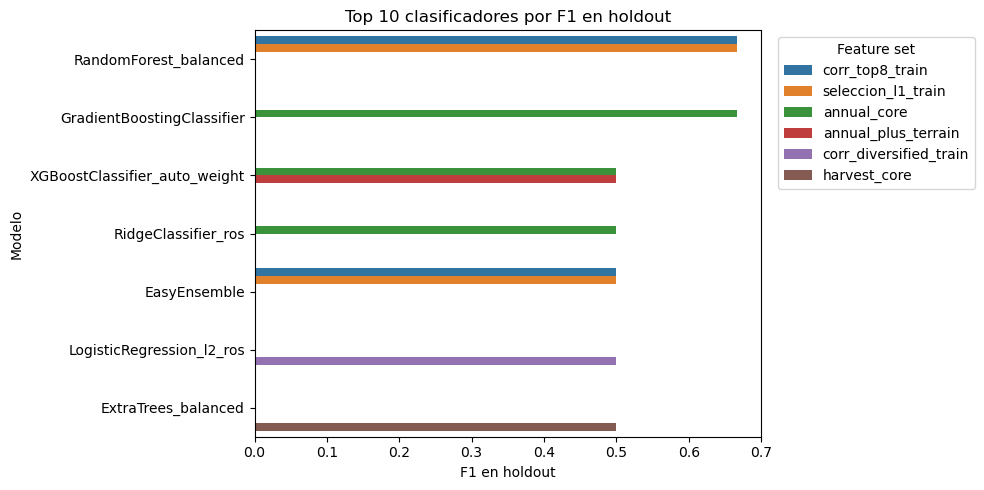

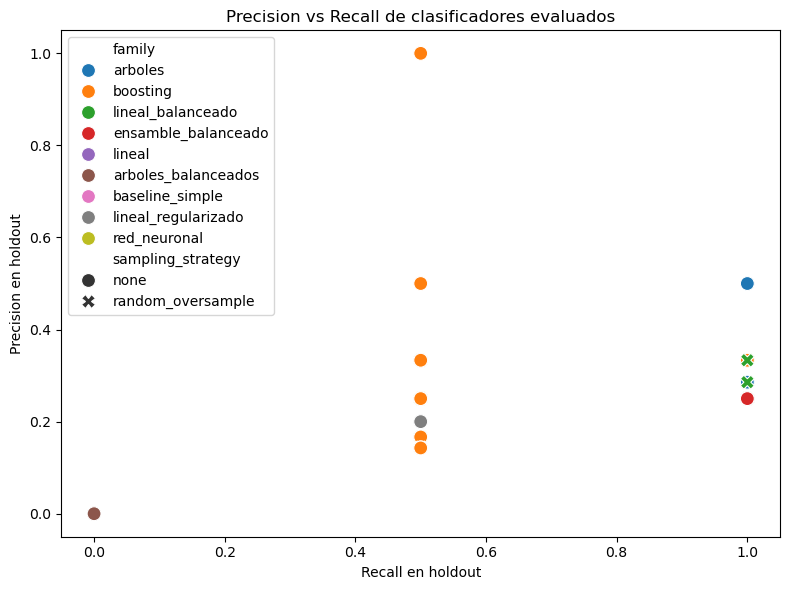

In [18]:
if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    plot_df = top_general_models.head(10).copy()
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x='test_f1', y='model_name', hue='feature_set', orient='h')
    plt.title('Top 10 clasificadores por F1 en holdout')
    plt.xlabel('F1 en holdout')
    plt.ylabel('Modelo')
    plt.legend(title='Feature set', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=test_results_df,
        x='test_recall',
        y='test_precision',
        hue='family',
        style='sampling_strategy',
        s=100,
    )
    plt.title('Precision vs Recall de clasificadores evaluados')
    plt.xlabel('Recall en holdout')
    plt.ylabel('Precision en holdout')
    plt.tight_layout()
    plt.show()
else:
    print('No hay graficas disponibles en este entorno o faltan resultados.')


## Exportacion de resultados y log de corrida

Se guardan tablas, configuracion y trazas de la corrida para facilitar auditoria, comparacion posterior y uso en el informe tecnico.


In [19]:
export_status = []

try:
    dependency_report.to_csv(OUTPUT_DIR / 'dependencias_detectadas.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': f'fallo: {exc}'})

try:
    feature_sets_table.to_csv(OUTPUT_DIR / 'feature_sets_utilizados.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': f'fallo: {exc}'})

try:
    fold_summary.to_csv(OUTPUT_DIR / 'resumen_folds_temporales.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'resumen_folds_temporales.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'resumen_folds_temporales.csv', 'estado': f'fallo: {exc}'})

if len(cv_results_df) > 0:
    try:
        cv_results_df.to_csv(OUTPUT_DIR / 'resumen_cv_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': f'fallo: {exc}'})

if len(test_results_df) > 0:
    try:
        test_results_df.to_csv(OUTPUT_DIR / 'resumen_test_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': f'fallo: {exc}'})

if len(event_priority_models) > 0:
    try:
        event_priority_models.to_csv(OUTPUT_DIR / 'resumen_test_modelos_priorizando_eventos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': f'fallo: {exc}'})

if len(predictions_df) > 0:
    try:
        predictions_df.to_csv(OUTPUT_DIR / 'predicciones_holdout_todos_los_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_predictions) > 0:
    try:
        top_predictions.to_csv(OUTPUT_DIR / 'predicciones_top_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_models_summary) > 0:
    try:
        top_models_summary.to_csv(OUTPUT_DIR / 'top_modelos_seleccionados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': f'fallo: {exc}'})

if len(candidate_models) > 0:
    try:
        candidate_models.to_csv(OUTPUT_DIR / 'candidatos_modelos_por_objetivo.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': f'fallo: {exc}'})

if len(candidate_summary) > 0:
    try:
        candidate_summary.to_csv(OUTPUT_DIR / 'resumen_candidatos_recomendados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': f'fallo: {exc}'})

if len(family_summary) > 0:
    try:
        family_summary.to_csv(OUTPUT_DIR / 'resumen_por_familia.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_por_familia.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_por_familia.csv', 'estado': f'fallo: {exc}'})

if len(adjustments_log) > 0:
    try:
        adjustments_log.to_csv(OUTPUT_DIR / 'ajustes_modelado_clasificacion.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'ajustes_modelado_clasificacion.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'ajustes_modelado_clasificacion.csv', 'estado': f'fallo: {exc}'})

if len(limitations_and_next_steps) > 0:
    try:
        limitations_and_next_steps.to_csv(OUTPUT_DIR / 'limitaciones_y_siguientes_refinamientos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': f'fallo: {exc}'})

config_payload = {
    'target': TARGET,
    'support_target': SUPPORT_TARGET,
    'train_end_year': TRAIN_END_YEAR,
    'test_start_year': TEST_START_YEAR,
    'small_train_end_year': SMALL_TRAIN_END_YEAR,
    'small_valid_end_year': SMALL_VALID_END_YEAR,
    'cv_min_train_years': CV_MIN_TRAIN_YEARS,
    'cv_valid_window': CV_VALID_WINDOW,
    'thresholds': THRESHOLDS,
    'feature_sets': {k: list(v) for k, v in feature_sets.items()},
    'dependency_status': dependency_status_text(dependency_report),
    'n_model_specs': len(model_specs),
}
try:
    safe_write_text(OUTPUT_DIR / 'config_experimento.json', json.dumps(config_payload, ensure_ascii=False, indent=2))
    export_status.append({'archivo': 'config_experimento.json', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'config_experimento.json', 'estado': f'fallo: {exc}'})

safe_write_text(OUTPUT_DIR / 'baseline_clasificacion_run_log.txt', '\n'.join(run_log))
export_status.append({'archivo': 'baseline_clasificacion_run_log.txt', 'estado': 'ok o intento de escritura realizado'})

export_status_df = pd.DataFrame(export_status)
display(export_status_df)


,archivo,estado
0,dependencias_detectadas.csv,ok
1,feature_sets_utilizados.csv,ok
2,resumen_folds_temporales.csv,ok
3,resumen_cv_modelos.csv,ok
4,resumen_test_modelos.csv,ok
5,resumen_test_modelos_priorizando_eventos.csv,ok
6,predicciones_holdout_todos_los_modelos.csv,ok
7,predicciones_top_modelos.csv,ok
8,top_modelos_seleccionados.csv,ok
9,candidatos_modelos_por_objetivo.csv,ok


## Lectura final del bloque de clasificacion

El valor de este cuaderno no esta solo en encontrar un clasificador ganador. Tambien deja trazable como cambian las conclusiones cuando se privilegia desempeno general o sensibilidad a eventos, y prepara la articulacion con la capa operacional mensual de clasificacion.


In [20]:
final_summary = []

if len(test_results_df) > 0:
    best_general = top_general_models.iloc[0]
    best_event = event_priority_models.iloc[0] if len(event_priority_models) > 0 else best_general
    final_summary.extend([
        {'tema': 'mejor_clasificador_general', 'lectura': f"{best_general['model_name']} con feature_set {best_general['feature_set']}"},
        {'tema': 'mejor_f1_holdout', 'lectura': f"{best_general['test_f1']:.4f}"},
        {'tema': 'mejor_balanced_accuracy_holdout', 'lectura': f"{best_general['test_balanced_accuracy']:.4f}"},
        {'tema': 'umbral_mejor_modelo_general', 'lectura': f"{best_general['threshold_used']:.2f}"},
        {'tema': 'mejor_clasificador_eventos', 'lectura': f"{best_event['model_name']} con feature_set {best_event['feature_set']}"},
        {'tema': 'recall_mejor_modelo_eventos', 'lectura': f"{best_event['test_recall']:.4f}"},
        {'tema': 'f1_mejor_modelo_eventos', 'lectura': f"{best_event['test_f1']:.4f}"},
        {'tema': 'necesidad_de_capa_operacional_clasificacion', 'lectura': 'si, para traducir estos hallazgos a alertas mensuales y trigger'},
    ])
else:
    final_summary.append({'tema': 'estado', 'lectura': 'no se generaron resultados de clasificacion'})

display(pd.DataFrame(final_summary))
print('Notebook 11_v2 listo.')


,tema,lectura
0,mejor_clasificador_general,RandomForest_balanced con feature_set corr_top...
1,mejor_f1_holdout,0.6667
2,mejor_balanced_accuracy_holdout,0.8333
3,umbral_mejor_modelo_general,0.15
4,mejor_clasificador_eventos,RandomForest_balanced con feature_set corr_top...
5,recall_mejor_modelo_eventos,1.0000
6,f1_mejor_modelo_eventos,0.6667
7,necesidad_de_capa_operacional_clasificacion,"si, para traducir estos hallazgos a alertas me..."


Notebook 11_v2 listo.
